# Impact of Autonomous Driving on EV Purchase Intention

**Project**: 15th National University Student Marketing Research Competition  
**Period**: December 2024 – March 2025  
**Author**: Ye Mingyu  

---

## Overview

This study examines how autonomous driving features influence consumers' willingness to pay a premium for EVs. Using ordinal logistic regression and mediation analysis on 622 survey responses, we investigate:

- **H1**: Technology trust positively affects purchase intention  
- **H2**: Perceived value of autonomous driving features positively affects purchase intention  
- **H3**: Driving pleasure and travel efficiency mediate these relationships

## 1. Setup

In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import shap

# Project root — auto-detect
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_FILE = PROJECT_ROOT / "data" / "raw" / "data.csv"

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("Dependencies loaded")

Dependencies loaded


## 2. Data Loading & Preprocessing

In [2]:
# Load data
df = pd.read_csv(DATA_FILE)
print(f"N = {df.shape[0]}, variables = {df.shape[1]}")

# Variable mapping
Q_COLS = {
    'Y': '21.您愿意为智能驾驶功能支付溢价?',
    'tech_trust_q1': '15.您认为智能驾驶功能对新能源汽车很重要?',
    'tech_trust_q2': '16.您认为智能驾驶功能可以提高驾驶安全性?',
    'perceived_value': '22.您愿意为智能驾驶的自适应巡航功能影响购买意愿?',
    'M1': '18.您认为智能驾驶功能可以提升驾驶乐趣?',
    'M2': '19.您认为智能驾驶功能可以提高出行效率?',
}

CONTROL_COLS = {
    'gender': '1.您的性别是?',
    'age': '2.您的年龄是?',
    'education': '4.您的最高学历是?',
    'income': '6.您的月收入范围是?',
    'driving_exp': '9.您的驾龄是?',
    'driving_freq': '12.您每周驾驶的频率是?',
}

# Construct analysis variables
df['Y'] = df[Q_COLS['Y']]
df['tech_trust'] = df[[Q_COLS['tech_trust_q1'], Q_COLS['tech_trust_q2']]].mean(axis=1)
df['perceived_value'] = df[Q_COLS['perceived_value']]
df['M1'] = df[Q_COLS['M1']]
df['M2'] = df[Q_COLS['M2']]

for name, col in CONTROL_COLS.items():
    df[name] = df[col]

print(f"Valid samples: {df['Y'].notna().sum()}")
print(df[['Y', 'tech_trust', 'perceived_value']].describe().round(3))

N = 622, variables = 67
Valid samples: 622
             Y  tech_trust  perceived_value
count  622.000     622.000          622.000
mean     3.572       3.803            3.603
std      1.087       1.055            1.083
min      1.000       1.000            1.000
25%      3.000       3.500            3.000
50%      4.000       4.000            4.000
75%      4.000       4.500            4.000
max      5.000       5.000            5.000


## 3. Ordinal Logistic Regression

In [3]:
def p_stars(p):
    if np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return ''

MAIN_VARS = ['tech_trust', 'perceived_value']
all_vars = MAIN_VARS + list(CONTROL_COLS.keys())
var_names_cn = ['Tech Trust', 'Perceived Value']

# Prepare data
X = df[all_vars].copy()
y = df['Y'].copy()
valid = ~(X.isnull().any(axis=1) | y.isnull())
X_v = X[valid].reset_index(drop=True)
y_v = y[valid].reset_index(drop=True)

print(f"Valid samples: {valid.sum()}")

# VIF check
print("\n--- VIF ---")
vif_data = []
for i, name in enumerate(all_vars):
    vif = variance_inflation_factor(X_v.values.astype(float), i)
    vif_data.append({'Variable': name, 'VIF': round(vif, 2)})
print(pd.DataFrame(vif_data).to_string(index=False))

# Model 1: core variables only
print("\n--- Model 1: Core Variables ---")
X1 = X_v[MAIN_VARS]
model1 = OrderedModel(y_v.values, X1.values, distr='logit')
res1 = model1.fit(method='bfgs', disp=False)
for i, name in enumerate(var_names_cn):
    b, p = res1.params[i], res1.pvalues[i]
    print(f"  {name}: B={b:.4f}, OR={np.exp(b):.4f}, p={p:.4f} {p_stars(p)}")

# Model 2: with controls
print("\n--- Model 2: With Controls ---")
model2 = OrderedModel(y_v.values, X_v.values, distr='logit')
res2 = model2.fit(method='bfgs', disp=False)
for i, name in enumerate(var_names_cn):
    b, p = res2.params[i], res2.pvalues[i]
    print(f"  {name}: B={b:.4f}, OR={np.exp(b):.4f}, p={p:.4f} {p_stars(p)}")

Valid samples: 622

--- VIF ---
       Variable   VIF
     tech_trust 26.37
perceived_value 23.96
         gender 10.55
            age  4.00
      education  5.70
         income  5.11
    driving_exp  4.11
   driving_freq  3.91

--- Model 1: Core Variables ---
  Tech Trust: B=1.0215, OR=2.7775, p=0.0000 ***
  Perceived Value: B=0.7881, OR=2.1993, p=0.0000 ***

--- Model 2: With Controls ---
  Tech Trust: B=1.0240, OR=2.7844, p=0.0000 ***
  Perceived Value: B=0.7919, OR=2.2075, p=0.0000 ***


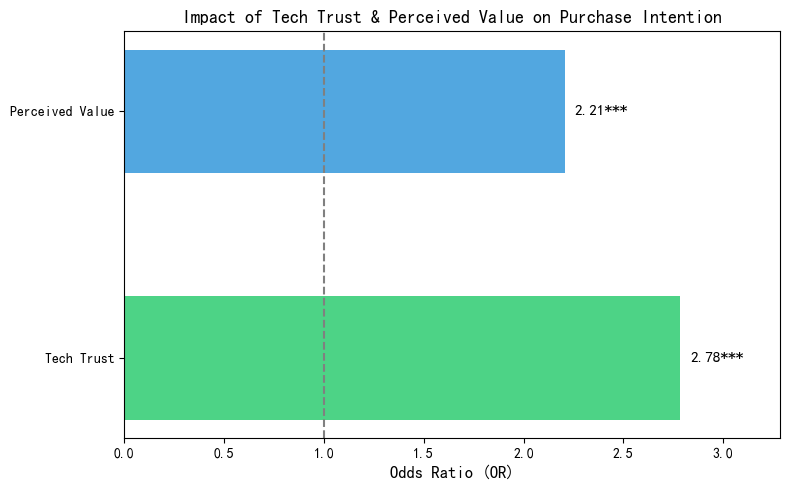

In [4]:
# Odds Ratio visualization
fig, ax = plt.subplots(figsize=(8, 5))
ors = [np.exp(res2.params[i]) for i in range(2)]
pvals = [res2.pvalues[i] for i in range(2)]
colors = ['#2ecc71', '#3498db']

bars = ax.barh(var_names_cn, ors, color=colors, alpha=0.85, height=0.5)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5)

for bar, or_val, p_val in zip(bars, ors, pvals):
    ax.text(or_val + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{or_val:.2f}{p_stars(p_val)}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Odds Ratio (OR)', fontsize=12)
ax.set_title('Impact of Tech Trust & Perceived Value on Purchase Intention', fontsize=13)
ax.set_xlim(0, max(ors) + 0.5)
plt.tight_layout()
plt.show()

## 4. Mediation Analysis

In [5]:
# Z-score standardization
def zscore(x):
    return (x - x.mean()) / x.std()

df_med = df[['tech_trust', 'perceived_value', 'M1', 'M2', 'Y'] + list(CONTROL_COLS.keys())].dropna().copy()
for v in ['tech_trust', 'perceived_value', 'M1', 'M2', 'Y']:
    df_med[v + '_z'] = zscore(df_med[v])

N = len(df_med)

def ols_fit(Y_col, X_list, data):
    X = sm.add_constant(data[X_list].values)
    return sm.OLS(data[Y_col].values, X).fit()

def mediation(X_var, M_var, Y_var, X_name, M_name):
    # Path c: X -> Y
    res_c = ols_fit(Y_var, [X_var], df_med)
    # Path a: X -> M
    res_a = ols_fit(M_var, [X_var], df_med)
    # Paths b, c': M, X -> Y
    res_bc = ols_fit(Y_var, [X_var, M_var], df_med)

    c = res_c.params[1]
    a = res_a.params[1]
    b = res_bc.params[2]
    c_prime = res_bc.params[1]
    indirect = a * b

    # Bootstrap (5000 iterations)
    np.random.seed(42)
    boot_indirect = []
    for _ in range(5000):
        idx = np.random.choice(N, N, replace=True)
        bd = df_med.iloc[idx]
        ra = ols_fit(M_var, [X_var], bd)
        rb = ols_fit(Y_var, [X_var, M_var], bd)
        boot_indirect.append(ra.params[1] * rb.params[2])
    boot_indirect = np.array(boot_indirect)

    ci_low, ci_high = np.percentile(boot_indirect, [2.5, 97.5])
    med_ratio = indirect / c * 100 if c != 0 else 0

    return {
        'X': X_name, 'M': M_name,
        'c': c, 'a': a, 'b': b, 'c_prime': c_prime,
        'indirect': indirect, 'ci_low': ci_low, 'ci_high': ci_high,
        'ratio': med_ratio, 'boot_indirect': boot_indirect
    }

paths = [
    ('tech_trust_z', 'M1_z', 'Y_z', 'Tech Trust', 'Driving Pleasure'),
    ('tech_trust_z', 'M2_z', 'Y_z', 'Tech Trust', 'Travel Efficiency'),
    ('perceived_value_z', 'M1_z', 'Y_z', 'Perceived Value', 'Driving Pleasure'),
    ('perceived_value_z', 'M2_z', 'Y_z', 'Perceived Value', 'Travel Efficiency'),
    ('tech_trust_z', 'perceived_value_z', 'Y_z', 'Tech Trust', 'Perceived Value'),
]

print("Mediation Analysis (Bootstrap 5000)")
print("=" * 60)

results = {}
for x_v, m_v, y_v, x_n, m_n in paths:
    r = mediation(x_v, m_v, y_v, x_n, m_n)
    results[f"{x_n}->{m_n}"] = r
    sig = "✓" if r['ci_low'] > 0 or r['ci_high'] < 0 else "✗"
    print(f"\n{x_n} -> {m_n} -> Purchase Intention")
    print(f"  Indirect={r['indirect']:.4f}, 95%CI=[{r['ci_low']:.4f}, {r['ci_high']:.4f}], Ratio={r['ratio']:.1f}% {sig}")

Mediation Analysis (Bootstrap 5000)

Tech Trust -> Driving Pleasure -> Purchase Intention
  Indirect=0.2402, 95%CI=[0.1671, 0.3109], Ratio=36.4% ✓

Tech Trust -> Travel Efficiency -> Purchase Intention
  Indirect=0.1737, 95%CI=[0.0968, 0.2461], Ratio=26.3% ✓

Perceived Value -> Driving Pleasure -> Purchase Intention
  Indirect=0.2480, 95%CI=[0.1929, 0.3056], Ratio=39.3% ✓

Perceived Value -> Travel Efficiency -> Purchase Intention
  Indirect=0.2040, 95%CI=[0.1480, 0.2614], Ratio=32.3% ✓

Tech Trust -> Perceived Value -> Purchase Intention
  Indirect=0.2319, 95%CI=[0.1605, 0.3022], Ratio=35.1% ✓


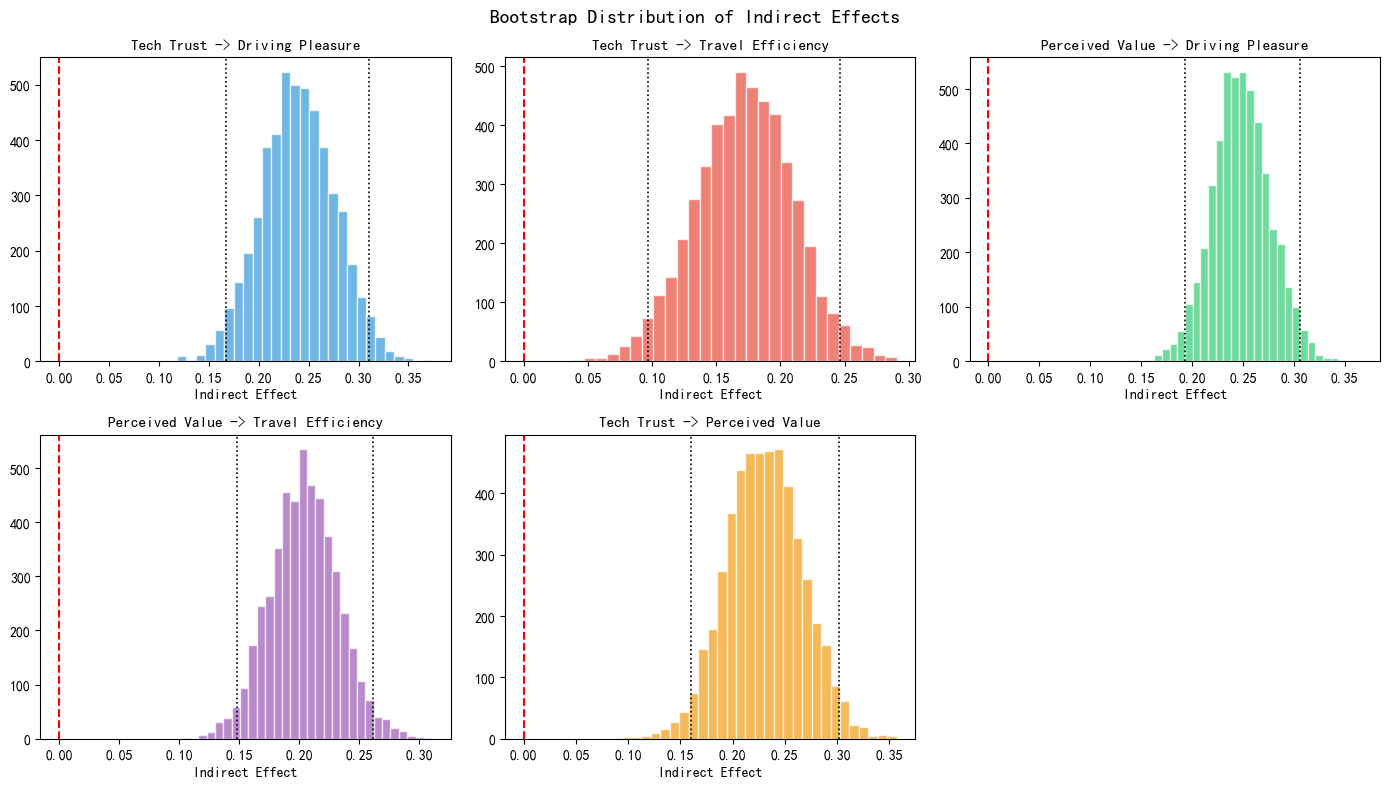

In [6]:
# Bootstrap distribution plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for idx, (key, r) in enumerate(results.items()):
    ax = axes[idx // 3, idx % 3]
    ax.hist(r['boot_indirect'], bins=30, color=colors[idx], alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(r['ci_low'], color='black', linestyle=':', linewidth=1.2)
    ax.axvline(r['ci_high'], color='black', linestyle=':', linewidth=1.2)
    ax.set_title(f"{r['X']} -> {r['M']}", fontsize=11)
    ax.set_xlabel('Indirect Effect')

axes[1, 2].axis('off')
plt.suptitle('Bootstrap Distribution of Indirect Effects', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Heterogeneity Analysis

In [7]:
def heterogeneity_test(df_in, group_col, group_name):
    print(f"\n--- {group_name} ---")
    groups = df_in[group_col].dropna().unique()
    if len(groups) < 2:
        print(f"  Insufficient groups, skipped")
        return None

    print(f"  Groups: {dict(zip(*np.unique(groups, return_counts=True)))}")

    group_results = {}
    for g in groups:
        mask = df_in[group_col] == g
        if mask.sum() < 30:
            continue
        X_g = df_in.loc[mask, MAIN_VARS]
        y_g = df_in.loc[mask, 'Y']
        try:
            m = OrderedModel(y_g.values, X_g.values, distr='logit')
            r = m.fit(method='bfgs', disp=False)
            group_results[g] = r
        except:
            pass

    if len(group_results) >= 2:
        for g, r in group_results.items():
            print(f"  Group {g}: n={len(y_g)}, OR_tt={np.exp(r.params[0]):.2f}, OR_pv={np.exp(r.params[1]):.2f}")

    return group_results

df_het = df[['tech_trust', 'perceived_value', 'Y', 'gender', 'age', 'education',
             'income', 'driving_exp', 'driving_freq']].dropna()

for col, name in [('gender', 'Gender'), ('age', 'Age'), ('education', 'Education'),
                   ('income', 'Income'), ('driving_exp', 'Driving Experience')]:
    heterogeneity_test(df_het, col, name)


--- Gender ---
  Groups: {1: 1, 2: 1}
  Group 2: n=179, OR_tt=2.38, OR_pv=2.39
  Group 1: n=179, OR_tt=4.54, OR_pv=1.84

--- Age ---
  Groups: {1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  Group 2: n=69, OR_tt=2.22, OR_pv=2.91
  Group 5: n=69, OR_tt=7.31, OR_pv=1.48
  Group 4: n=69, OR_tt=2.32, OR_pv=3.84
  Group 1: n=69, OR_tt=2.36, OR_pv=2.33
  Group 3: n=69, OR_tt=6.22, OR_pv=0.84

--- Education ---
  Groups: {1: 1, 2: 1, 3: 1, 4: 1}
  Group 2: n=173, OR_tt=4.13, OR_pv=2.50
  Group 1: n=173, OR_tt=3.20, OR_pv=1.58
  Group 4: n=173, OR_tt=2.58, OR_pv=3.17
  Group 3: n=173, OR_tt=2.20, OR_pv=1.94

--- Income ---
  Groups: {1: 1, 2: 1, 3: 1, 4: 1}
  Group 2: n=188, OR_tt=2.69, OR_pv=2.82
  Group 4: n=188, OR_tt=2.72, OR_pv=1.71
  Group 3: n=188, OR_tt=2.40, OR_pv=2.82
  Group 1: n=188, OR_tt=3.08, OR_pv=1.86

--- Driving Experience ---
  Groups: {1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
  Group 1: n=64, OR_tt=3.19, OR_pv=1.62
  Group 3: n=64, OR_tt=3.71, OR_pv=2.58
  Group 2: n=64, OR_tt=2.37, OR_pv=3.02
  G

## 6. Machine Learning + SHAP Analysis

In [8]:
# ML prediction model (Random Forest)
feature_cols = ['tech_trust', 'perceived_value'] + list(CONTROL_COLS.keys())
df_ml = df[feature_cols + ['Y']].dropna()
X_ml = df_ml[feature_cols]
y_ml = df_ml['Y']

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train, y_train)

acc = rf.score(X_test, y_test)
print(f"Random Forest Accuracy: {acc:.4f}")

# SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Feature names
feature_names = ['Tech Trust', 'Perceived Value', 'Gender', 'Age',
                 'Education', 'Income', 'Driving Exp', 'Driving Freq']

print("SHAP analysis complete")

Random Forest Accuracy: 0.5920
SHAP analysis complete


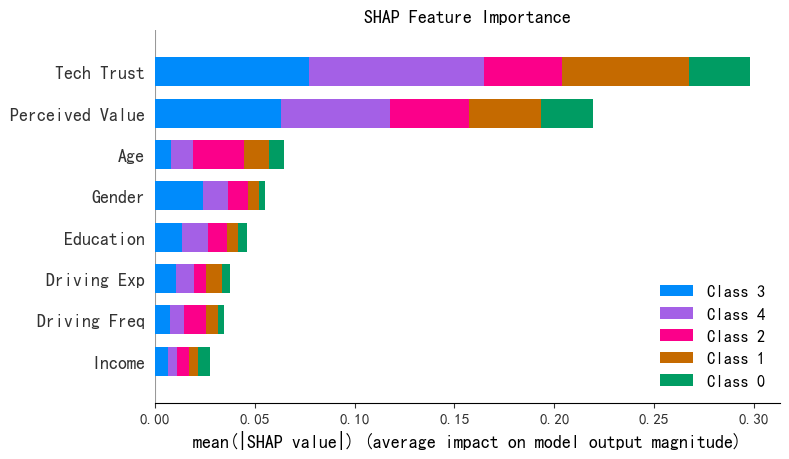

In [9]:
# SHAP Summary Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance", fontsize=13)
plt.tight_layout()
plt.show()

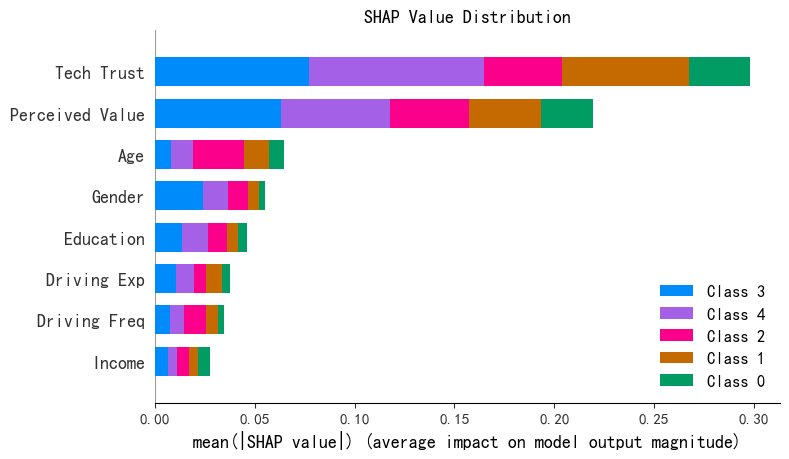

In [10]:
# SHAP Summary Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Value Distribution", fontsize=13)
plt.tight_layout()
plt.show()

---

**Analysis complete.**

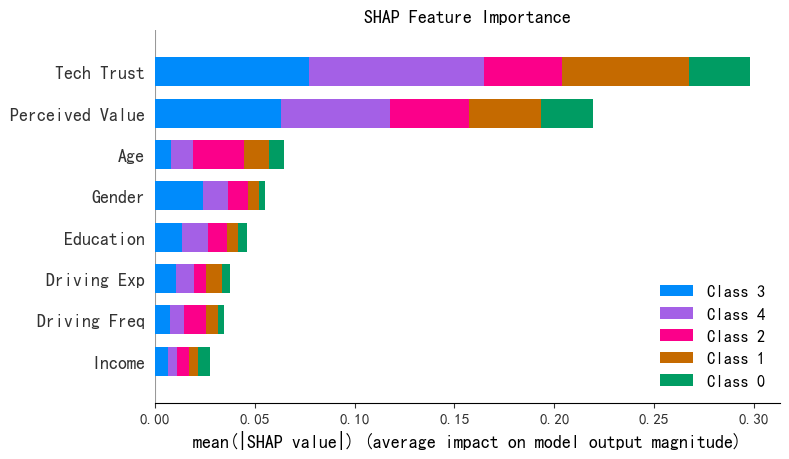

In [11]:
# SHAP Summary Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance", fontsize=13)
plt.tight_layout()
plt.show()

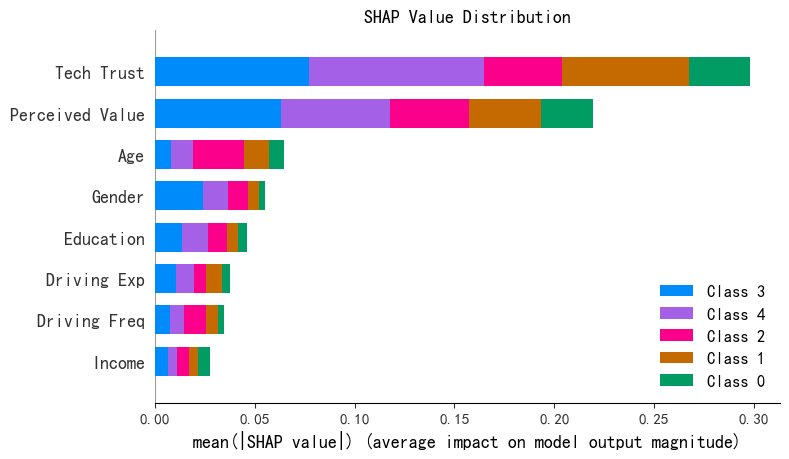

In [12]:
# SHAP Summary Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Value Distribution", fontsize=13)
plt.tight_layout()
plt.show()

---

**Analysis complete.**